In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from PIL import Image
import xml.etree.ElementTree as ET
from lxml import etree
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define paths
annotations_dir = "/Users/kushalgupta/Desktop/Helmet_Detection_yolov8/datasets/1/annotations"
images_dir = "/Users/kushalgupta/Desktop/Helmet_Detection_yolov8/datasets/1/images"

# Define classes
classes = ['With Helmet', 'Without Helmet']
class_dict = {'With Helmet': 0, 'Without Helmet': 1}
num_classes = len(classes)

ModuleNotFoundError: No module named 'albumentations'

In [31]:
class SimpleBackbone(nn.Module):
    def __init__(self, in_channels=3, out_channels=512):
        super(SimpleBackbone, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )
        
    def forward(self, x):
        return self.features(x)

class ROIPool(nn.Module):
    def __init__(self, output_size):
        super(ROIPool, self).__init__()
        self.output_size = output_size
        
    def forward(self, features, rois):
        batch_indices = rois[:, 0].long()
        boxes = rois[:, 1:]
        
        pooled_features = []
        for i, (batch_idx, box) in enumerate(zip(batch_indices, boxes)):
            x1, y1, x2, y2 = box
            x1 = int(x1 * features.size(3))
            y1 = int(y1 * features.size(2))
            x2 = int(x2 * features.size(3))
            y2 = int(y2 * features.size(2))
            
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(features.size(3), x2)
            y2 = min(features.size(2), y2)
            
            if x2 > x1 and y2 > y1:
                roi_feature = features[batch_idx, :, y1:y2, x1:x2]
                pooled = F.adaptive_max_pool2d(roi_feature, self.output_size)
                pooled_features.append(pooled)
            else:
                pooled_features.append(torch.zeros(features.size(1), self.output_size[0], self.output_size[1], device=features.device))
        
        return torch.stack(pooled_features)

class FastRCNN(nn.Module):
    def __init__(self, num_classes=2, roi_size=7):
        super(FastRCNN, self).__init__()
        self.num_classes = num_classes
        self.roi_size = roi_size
        
        self.backbone = SimpleBackbone()
        backbone_out_channels = 512
        
        self.roi_pool = ROIPool(output_size=(roi_size, roi_size))
        
        self.classifier = nn.Sequential(
            nn.Linear(backbone_out_channels * roi_size * roi_size, 1024),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(1024, 1024),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes)
        )
        
        self.bbox_pred = nn.Sequential(
            nn.Linear(backbone_out_channels * roi_size * roi_size, 1024),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(1024, 1024),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(1024, num_classes * 4)
        )
        
    def forward(self, images, rois):
        features = self.backbone(images)
        pooled_features = self.roi_pool(features, rois)
        batch_size, channels, height, width = pooled_features.size()
        pooled_features = pooled_features.view(batch_size, -1)
        
        class_logits = self.classifier(pooled_features)
        bbox_deltas = self.bbox_pred(pooled_features)
        bbox_deltas = bbox_deltas.view(batch_size, self.num_classes, 4)
        
        return class_logits, bbox_deltas

class FastRCNNLoss(nn.Module):
    def __init__(self, lambda_reg=1.0):
        super(FastRCNNLoss, self).__init__()
        self.lambda_reg = lambda_reg
        self.cls_loss = nn.CrossEntropyLoss()
        self.bbox_loss = nn.SmoothL1Loss()
    
    def forward(self, class_logits, bbox_deltas, labels, bbox_targets):
        cls_loss = self.cls_loss(class_logits, labels)
        
        pos_mask = labels > 0
        if pos_mask.sum() > 0:
            bbox_loss = self.bbox_loss(
                bbox_deltas[pos_mask, labels[pos_mask]],
                bbox_targets[pos_mask]
            )
        else:
            bbox_loss = torch.tensor(0.0, device=class_logits.device)
        
        total_loss = cls_loss + self.lambda_reg * bbox_loss
        return total_loss, cls_loss, bbox_loss

In [32]:
class HelmetDataset(Dataset):
    def __init__(self, annotations_dir, images_dir, split='train', img_size=224):
        self.annotations_dir = annotations_dir
        self.images_dir = images_dir
        self.img_size = img_size
        
        # Get all annotation files
        annotation_files = [f for f in os.listdir(annotations_dir) if f.endswith('.xml')]
        
        # Split data
        train_files, val_files = train_test_split(annotation_files, test_size=0.2, random_state=42)
        
        if split == 'train':
            self.files = train_files
        else:
            self.files = val_files
            
    def parse_annotation(self, annotation_file):
        """Parse XML annotations to extract bounding boxes and labels"""
        annotation_path = os.path.join(self.annotations_dir, annotation_file)
        try:
            tree = etree.parse(annotation_path)
            root = tree.getroot()
            
            objects = []
            for obj in root.findall('object'):
                obj_struct = {}
                obj_struct['name'] = obj.find('name').text
                bbox = obj.find('bndbox')
                obj_struct['bbox'] = [
                    int(float(bbox.find('xmin').text)),
                    int(float(bbox.find('ymin').text)),
                    int(float(bbox.find('xmax').text)),
                    int(float(bbox.find('ymax').text))
                ]
                objects.append(obj_struct)
            return objects
        except Exception as e:
            print(f"Error parsing {annotation_file}: {e}")
            return []
    
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        annotation_file = self.files[idx]
        
        # Parse annotation
        objects = self.parse_annotation(annotation_file)
        
        # Load image
        image_path = os.path.join(self.images_dir, annotation_file.replace('.xml', '.png'))
        image = cv2.imread(image_path)
        if image is None:
            # Try with different extensions
            for ext in ['.jpg', '.jpeg', '.JPG', '.JPEG']:
                image_path = os.path.join(self.images_dir, annotation_file.replace('.xml', ext))
                image = cv2.imread(image_path)
                if image is not None:
                    break
        
        if image is None:
            # Return a dummy sample if image not found
            print(f"Image not found: {image_path}")
            image = np.ones((224, 224, 3), dtype=np.uint8) * 128
            objects = [{'name': 'With Helmet', 'bbox': [50, 50, 100, 100]}]
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_h, original_w = image.shape[:2]
        
        # Prepare bounding boxes and labels
        boxes = []
        labels = []
        
        for obj in objects:
            xmin, ymin, xmax, ymax = obj['bbox']
            class_id = class_dict[obj['name']]
            
            # Normalize coordinates and clamp to [0, 1]
            xmin_norm = max(0.0, min(1.0, xmin / original_w))
            ymin_norm = max(0.0, min(1.0, ymin / original_h))
            xmax_norm = max(0.0, min(1.0, xmax / original_w))
            ymax_norm = max(0.0, min(1.0, ymax / original_h))
            
            # Skip invalid boxes
            if xmax_norm > xmin_norm and ymax_norm > ymin_norm:
                boxes.append([xmin_norm, ymin_norm, xmax_norm, ymax_norm])
                labels.append(class_id)
        
        if len(boxes) == 0:
            # If no valid objects, return dummy data
            boxes = [[0.1, 0.1, 0.5, 0.5]]
            labels = [0]
        
        # Resize image
        image = cv2.resize(image, (self.img_size, self.img_size))
        
        # Convert to tensor and normalize
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        
        boxes_tensor = torch.tensor(boxes, dtype=torch.float32)
        labels_tensor = torch.tensor(labels, dtype=torch.long)
        
        return image_tensor, {'boxes': boxes_tensor, 'labels': labels_tensor, 'image_id': idx}

In [33]:
def train_fast_rcnn():
    print("Initializing Fast R-CNN Training...")
    
    # Create datasets (without albumentations for simplicity)
    train_dataset = HelmetDataset(annotations_dir, images_dir, split='train', img_size=224)
    val_dataset = HelmetDataset(annotations_dir, images_dir, split='val', img_size=224)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    
    # Custom collate function
    def collate_fn(batch):
        images = []
        targets = []
        
        for item in batch:
            images.append(item[0])
            targets.append(item[1])
        
        # Stack images
        images = torch.stack(images, dim=0)
        return images, targets
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=collate_fn, num_workers=0)
    
    # Initialize model
    model = FastRCNN(num_classes=num_classes).to(device)
    criterion = FastRCNNLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    
    # Training loop
    num_epochs = 20  # Reduced for faster training
    train_losses = []
    val_accuracies = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        batch_count = 0
        
        for batch_idx, (images, targets) in enumerate(train_loader):
            images = images.to(device)
            
            # Prepare ROIs from ground truth boxes
            batch_rois = []
            batch_labels = []
            batch_bbox_targets = []
            
            for i, target in enumerate(targets):
                boxes = target['boxes']
                labels = target['labels']
                
                if len(boxes) == 0:
                    continue
                    
                # Add batch index to boxes
                batch_indices = torch.full((len(boxes), 1), i, dtype=torch.float32)
                rois = torch.cat([batch_indices, boxes], dim=1)
                batch_rois.append(rois)
                batch_labels.append(labels)
                
                # For simplicity, use zero bbox targets
                bbox_targets = torch.zeros((len(boxes), 4), dtype=torch.float32)
                batch_bbox_targets.append(bbox_targets)
            
            if len(batch_rois) == 0:
                continue
                
            batch_rois = torch.cat(batch_rois, dim=0).to(device)
            batch_labels = torch.cat(batch_labels, dim=0).to(device)
            batch_bbox_targets = torch.cat(batch_bbox_targets, dim=0).to(device)
            
            # Forward pass
            optimizer.zero_grad()
            class_logits, bbox_deltas = model(images, batch_rois)
            
            # Compute loss
            total_loss, cls_loss, bbox_loss = criterion(
                class_logits, bbox_deltas, batch_labels, batch_bbox_targets
            )
            
            # Backward pass
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += total_loss.item()
            batch_count += 1
            
            if batch_idx % 10 == 0:
                print(f'Epoch: {epoch+1}/{num_epochs}, Batch: {batch_idx}, Loss: {total_loss.item():.4f}')
        
        if batch_count > 0:
            avg_loss = epoch_loss / batch_count
        else:
            avg_loss = 0
            
        train_losses.append(avg_loss)
        
        # Validation
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device)
                
                batch_rois = []
                batch_labels = []
                
                for i, target in enumerate(targets):
                    boxes = target['boxes']
                    labels = target['labels']
                    
                    if len(boxes) == 0:
                        continue
                        
                    batch_indices = torch.full((len(boxes), 1), i, dtype=torch.float32)
                    rois = torch.cat([batch_indices, boxes], dim=1)
                    batch_rois.append(rois)
                    batch_labels.append(labels)
                
                if len(batch_rois) == 0:
                    continue
                    
                batch_rois = torch.cat(batch_rois, dim=0).to(device)
                batch_labels = torch.cat(batch_labels, dim=0).to(device)
                
                class_logits, _ = model(images, batch_rois)
                preds = torch.argmax(class_logits, dim=1)
                correct += (preds == batch_labels).sum().item()
                total += len(batch_labels)
        
        accuracy = correct / total if total > 0 else 0
        val_accuracies.append(accuracy)
        
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Val Accuracy: {accuracy:.4f}')
    
    # Save model
    torch.save(model.state_dict(), 'fast_rcnn_helmet_detection.pth')
    print("Model saved as 'fast_rcnn_helmet_detection.pth'")
    
    return model, train_losses, val_accuracies
#if __name__ == "__main__":
#    model, train_losses, val_accuracies = train_fast_rcnn()
#import os
#import cv2
#import numpy as np
#import matplotlib.pyplot as plt
#import torch    

In [34]:
def generate_proposals(image_width, image_height, min_size=50, max_size=200, stride=50):
    """Generate region proposals using sliding window"""
    proposals = []
    
    for size in range(min_size, min(max_size, min(image_width, image_height)), 50):
        for y in range(0, image_height - size + 1, stride):
            for x in range(0, image_width - size + 1, stride):
                proposals.append([x, y, x + size, y + size])
    
    return proposals

def fast_rcnn_inference(model, image_path, confidence_threshold=0.5):
    """Perform inference using trained Fast R-CNN model"""
    model.eval()
    
    # Load and preprocess image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Could not load image: {image_path}")
        return [], None
        
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_h, original_w = image_rgb.shape[:2]
    
    # Preprocess image
    image_resized = cv2.resize(image_rgb, (224, 224))
    image_tensor = torch.from_numpy(image_resized).permute(2, 0, 1).float() / 255.0
    image_tensor = image_tensor.unsqueeze(0).to(device)
    
    # Generate region proposals using sliding window
    proposals = generate_proposals(original_w, original_h)
    
    # Convert proposals to ROI format
    rois = []
    for proposal in proposals:
        x1, y1, x2, y2 = proposal
        # Normalize coordinates
        x1_norm = x1 / original_w
        y1_norm = y1 / original_h
        x2_norm = x2 / original_w
        y2_norm = y2 / original_h
        rois.append([0, x1_norm, y1_norm, x2_norm, y2_norm])  # batch index 0
    
    rois = torch.tensor(rois, dtype=torch.float32).to(device)
    
    # Perform inference
    with torch.no_grad():
        class_logits, bbox_deltas = model(image_tensor, rois)
        probabilities = F.softmax(class_logits, dim=1)
        max_probs, pred_classes = torch.max(probabilities, dim=1)
    
    # Filter detections
    detections = []
    for i, (prob, class_id) in enumerate(zip(max_probs, pred_classes)):
        if prob >= confidence_threshold and class_id > 0:  # Skip background
            x1, y1, x2, y2 = proposals[i]
            detections.append({
                'bbox': [x1, y1, x2, y2],
                'class_id': class_id.item(),
                'class_name': classes[class_id.item()],
                'confidence': prob.item()
            })
    
    return detections, image_rgb

def visualize_detections(image, detections):
    """Visualize detections on image"""
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Draw detections
    for detection in detections:
        bbox = detection['bbox']
        class_name = detection['class_name']
        confidence = detection['confidence']
        
        # Choose color based on class
        color = 'green' if class_name == 'With Helmet' else 'red'
        
        # Draw bounding box
        rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1],
                           fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)
        
        # Add label
        label = f'{class_name}: {confidence:.2f}'
        ax.text(bbox[0], bbox[1] - 10, label, color=color, fontsize=12, weight='bold')
    
    ax.imshow(image)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [35]:
# Train the model
print("Starting Fast R-CNN Training...")
model, train_losses, val_accuracies = train_fast_rcnn()

Starting Fast R-CNN Training...
Initializing Fast R-CNN Training...
Training samples: 611
Validation samples: 153
Epoch: 1/20, Batch: 0, Loss: 0.7029
Epoch: 1/20, Batch: 10, Loss: 0.6939
Epoch: 1/20, Batch: 20, Loss: 0.5447
Epoch: 1/20, Batch: 30, Loss: 0.4916
Epoch: 1/20, Batch: 40, Loss: 0.4243
Epoch: 1/20, Batch: 50, Loss: 0.5699
Epoch: 1/20, Batch: 60, Loss: 0.6680
Epoch: 1/20, Batch: 70, Loss: 0.7552
Epoch: 1/20, Batch: 80, Loss: 0.7519
Epoch: 1/20, Batch: 90, Loss: 0.7205
Epoch: 1/20, Batch: 100, Loss: 0.3604
Epoch: 1/20, Batch: 110, Loss: 0.6860
Epoch: 1/20, Batch: 120, Loss: 0.3583
Epoch: 1/20, Batch: 130, Loss: 0.1553
Epoch: 1/20, Batch: 140, Loss: 0.9914
Epoch: 1/20, Batch: 150, Loss: 0.7410
Epoch 1/20, Loss: 0.6417, Val Accuracy: 0.6622
Epoch: 2/20, Batch: 0, Loss: 0.6187
Epoch: 2/20, Batch: 10, Loss: 0.6934
Epoch: 2/20, Batch: 20, Loss: 0.5603
Epoch: 2/20, Batch: 30, Loss: 0.3419
Epoch: 2/20, Batch: 40, Loss: 0.5011
Epoch: 2/20, Batch: 50, Loss: 0.5550
Epoch: 2/20, Batch: 6

In [39]:
# Load the trained model
def load_trained_model(model_path):
    """Load the trained model from .pth file"""
    model = FastRCNN(num_classes=num_classes)
    
    if os.path.exists(model_path):
        print(f"Loading model from: {model_path}")
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.to(device)
        model.eval()
        print("Model loaded successfully!")
        return model
    else:
        print(f"Model file not found: {model_path}")
        print("Please make sure you have trained the model first.")
        return None

# Load your trained model
model_path = 'fast_rcnn_helmet_detection.pth'  # Path to your saved model
model = load_trained_model(model_path)

Loading model from: fast_rcnn_helmet_detection.pth
Model loaded successfully!


Testing on sample images...
Processing: BikesHelmets2.png


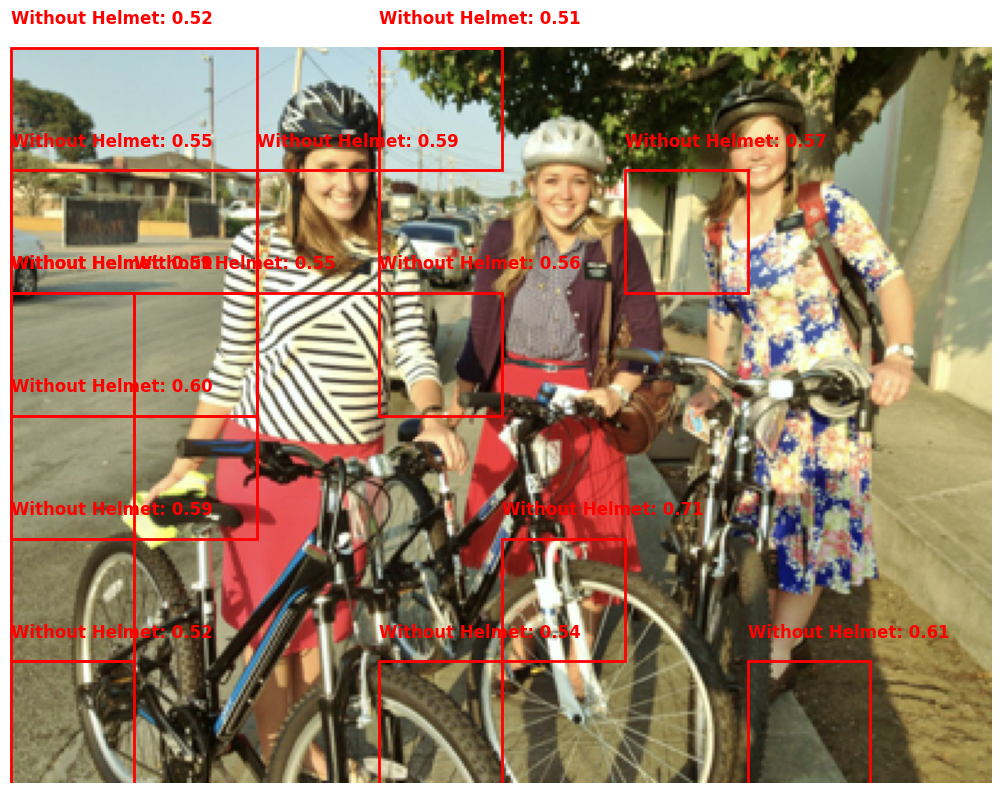

Detections in BikesHelmets2.png:
  - Without Helmet: 0.51
  - Without Helmet: 0.59
  - Without Helmet: 0.57
  - Without Helmet: 0.59
  - Without Helmet: 0.55
  - Without Helmet: 0.56
  - Without Helmet: 0.60
  - Without Helmet: 0.59
  - Without Helmet: 0.71
  - Without Helmet: 0.52
  - Without Helmet: 0.54
  - Without Helmet: 0.61
  - Without Helmet: 0.52
  - Without Helmet: 0.55
  - Without Helmet: 0.51

Fast R-CNN implementation completed!


In [41]:
# Test on sample images
print("Testing on sample images...")

# SPECIFY YOUR CUSTOM TEST IMAGE PATH HERE
custom_test_image_path = "/Users/kushalgupta/Desktop/Helmet_Detection_yolov8/datasets/1/images/BikesHelmets2.png"  # ← CHANGE THIS PATH

# Use your custom image path
test_images = [custom_test_image_path]

for img_path in test_images:
    if os.path.exists(img_path):
        print(f"Processing: {os.path.basename(img_path)}")
        
        detections, image = fast_rcnn_inference(model, img_path, confidence_threshold=0.5)
        visualize_detections(image, detections)
        
        print(f"Detections in {os.path.basename(img_path)}:")
        for det in detections:
            print(f"  - {det['class_name']}: {det['confidence']:.2f}")
        print()
    else:
        print(f"Test image not found: {img_path}")

print("Fast R-CNN implementation completed!")